# Application 3 — E-commerce Customer Behavior and Interest Discovery
### Assignment 02 — Intelligent System Development (PTIT)

**Pipeline:** `Raw Data -> Understand -> Clean -> Represent -> Learn -> Evaluate -> Persist -> Deploy`

**Dataset:** Women's Clothing E-Commerce Reviews (Kaggle) — `data/ecommerce_reviews.csv`.
One observation = **one customer review of one product**.

- `X` = the review's tabular attributes (age, rating, positive-feedback count, engineered
  review/title-length features) + the product's category attributes, **and** the free-text
  `Review Text`.
- `y` = `Recommended IND` — did the customer recommend the product (1) or not (0)?

This is a **binary classification** problem, with an additional twist: part of the input is
**unstructured text**, so this notebook also demonstrates the
`Text -> Tokens -> Token IDs/TF-IDF -> Vector` representation pipeline from Lecture 02.


In [1]:
import json
import os
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                              confusion_matrix, f1_score, precision_score, recall_score,
                              roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/ecommerce_reviews.csv"
CHART_DIR = "../charts"
MODEL_DIR = "../model"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

## 1–2. Raw Data & Data Understanding

In [2]:
df = pd.read_csv(DATA_PATH)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\nTarget distribution:")
df["Recommended IND"].value_counts()

Missing values per column:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Duplicated rows: 21

Target distribution:


Recommended IND
1    19314
0     4172
Name: count, dtype: int64

**Observations.** `Title` (16%) and `Review Text` (3.6%) are frequently missing — some
customers rate a product without writing a comment. `Division/Department/Class Name` are
missing for only 14 rows. The target is imbalanced: ~82% of reviews recommend the product.
There are 21 exact duplicate rows.

## 3. Data Cleaning

- 21 exact duplicate rows are removed.
- Invalid-value checks (`Age<=0`, `Rating` outside 1–5, target outside {0,1},
  `Positive Feedback Count<0`) find **zero** violations.
- Outliers (IQR) are detected in `Age` and `Positive Feedback Count` but **kept** — an older
  shopper or a review with many "helpful" votes is a genuine behaviour, not an error.
- The 14 rows missing product-category information are dropped (0.06% of the data — safe to
  discard).
- `Title`/`Review Text` missingness is **not** imputed with a placeholder string; instead it
  is turned into explicit features: `Has Title`, `Has Review`, `Title Length`,
  `Review Length` — this way "the customer chose not to write a review" remains a signal the
  model can use, instead of being hidden inside a fake value.


In [5]:
df_clean = df.drop_duplicates().copy()

invalid_checks = {
    "Age <= 0": (df_clean["Age"] <= 0).sum(),
    "Rating outside 1-5": (~df_clean["Rating"].between(1, 5)).sum(),
    "Recommended IND not 0/1": (~df_clean["Recommended IND"].isin([0, 1])).sum(),
    "Positive Feedback Count < 0": (df_clean["Positive Feedback Count"] < 0).sum(),
}
print("Invalid value counts:", invalid_checks)

for col in ["Age", "Positive Feedback Count"]:
    q1, q3 = df_clean[col].quantile([0.25, 0.75]); iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: bounds=({lower:.2f},{upper:.2f}) outliers={n_out}")

df_clean = df_clean.dropna(subset=["Division Name", "Department Name", "Class Name"])

df_clean["Review Text"] = df_clean["Review Text"].fillna("")
df_clean["Title"] = df_clean["Title"].fillna("")
df_clean["Has Review"] = (df_clean["Review Text"].str.len() > 0).astype(int)
df_clean["Has Title"] = (df_clean["Title"].str.len() > 0).astype(int)
df_clean["Review Length"] = df_clean["Review Text"].str.len()
df_clean["Title Length"] = df_clean["Title"].str.len()

print("Cleaned dataset shape:", df_clean.shape)

Invalid value counts: {'Age <= 0': np.int64(0), 'Rating outside 1-5': np.int64(0), 'Recommended IND not 0/1': np.int64(0), 'Positive Feedback Count < 0': np.int64(0)}
Age: bounds=(7.00,79.00) outliers=109
Positive Feedback Count: bounds=(-4.50,7.50) outliers=2147
Cleaned dataset shape: (23451, 14)


## 4. Data Representation

Each review becomes a feature vector combining seven numeric features (two of them raw:
`Age`, `Rating`, `Positive Feedback Count`; four engineered from the text: `Review Length`,
`Title Length`, `Has Review`, `Has Title`) and three one-hot-encoded categorical features
(`Division Name`, `Department Name`, `Class Name`), i.e. `X ∈ R^(N×d)`.

Separately, the raw `Review Text` column is kept aside to build a **text representation**
(`Text -> Tokens -> TF-IDF vector`) for a sixth, text-based model.

In [6]:
numeric_features = ["Age", "Rating", "Positive Feedback Count",
                     "Review Length", "Title Length", "Has Review", "Has Title"]
categorical_features = ["Division Name", "Department Name", "Class Name"]
target_col = "Recommended IND"
feature_cols = numeric_features + categorical_features

X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()
review_text = df_clean["Review Text"].copy()
print("X shape:", X.shape, " y shape:", y.shape)
X.dtypes

X shape: (23451, 10)  y shape: (23451,)


Age                        int64
Rating                     int64
Positive Feedback Count    int64
Review Length              int64
Title Length               int64
Has Review                 int64
Has Title                  int64
Division Name                str
Department Name              str
Class Name                   str
dtype: object

## 5. Exploratory Data Analysis (EDA)

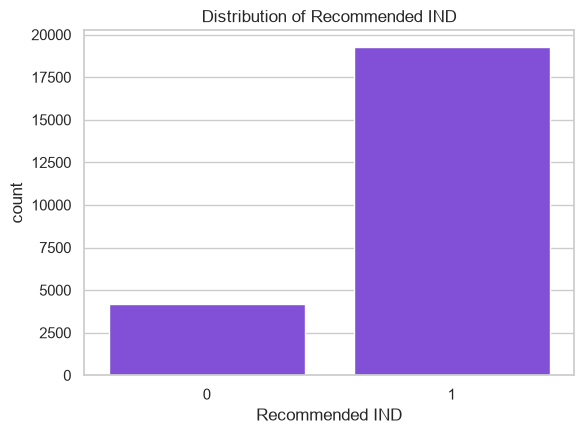

In [7]:
plt.figure(figsize=(6, 4.5))
sns.countplot(x=y, color="#7c3aed")
plt.title("Distribution of Recommended IND")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_target_distribution.png", dpi=120)
plt.show()

**Observation:** ~82% of reviews recommend the product (`1`), ~18% do not.
**ML implication:** because of this imbalance, `F1-score` (not raw `Accuracy`) is used as
the primary model-selection criterion.

<Figure size 700x450 with 0 Axes>

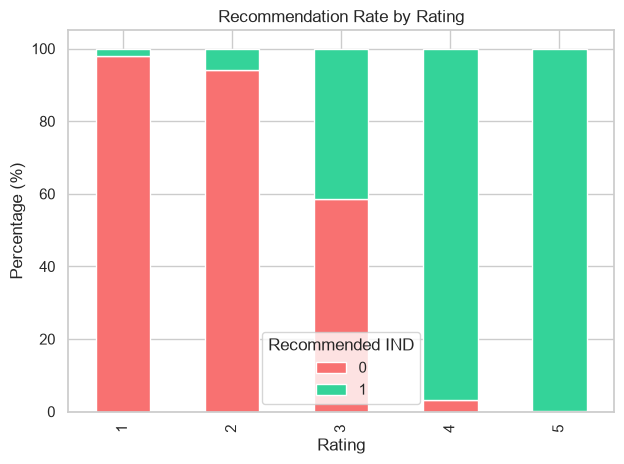

In [8]:
plt.figure(figsize=(7, 4.5))
ct = pd.crosstab(df_clean["Rating"], y, normalize="index") * 100
ct.plot(kind="bar", stacked=True, color=["#f87171", "#34d399"])
plt.title("Recommendation Rate by Rating")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_recommend_by_rating.png", dpi=120)
plt.show()

**Observation:** recommendation rate rises sharply with `Rating` (1-star reviews almost
never recommend; 5-star reviews almost always do). **ML implication:** `Rating` is expected
to be the single strongest predictor of `Recommended IND`.

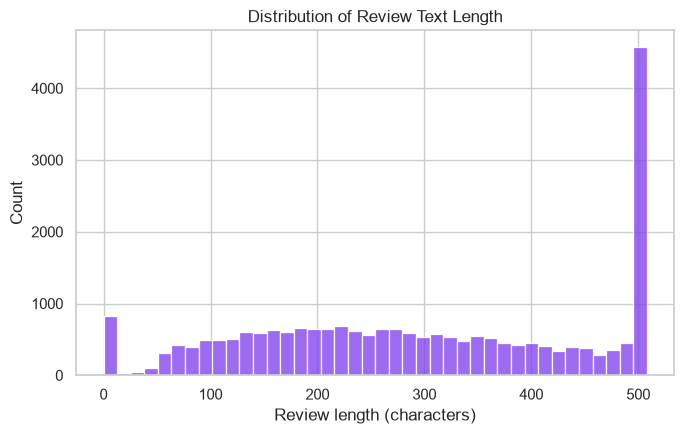

In [9]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_clean["Review Length"], bins=40, color="#7c3aed")
plt.title("Distribution of Review Text Length")
plt.xlabel("Review length (characters)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_review_length_distribution.png", dpi=120)
plt.show()

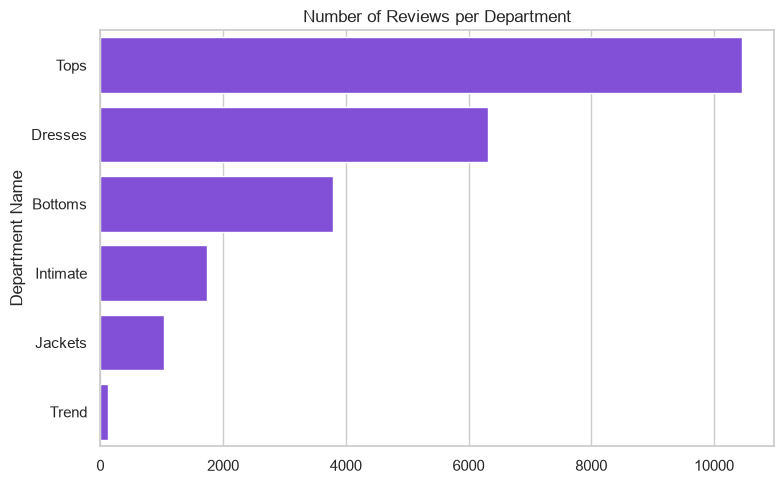

In [10]:
plt.figure(figsize=(8, 5))
top_dept = df_clean["Department Name"].value_counts()
sns.barplot(x=top_dept.values, y=top_dept.index, color="#7c3aed")
plt.title("Number of Reviews per Department")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_reviews_per_department.png", dpi=120)
plt.show()

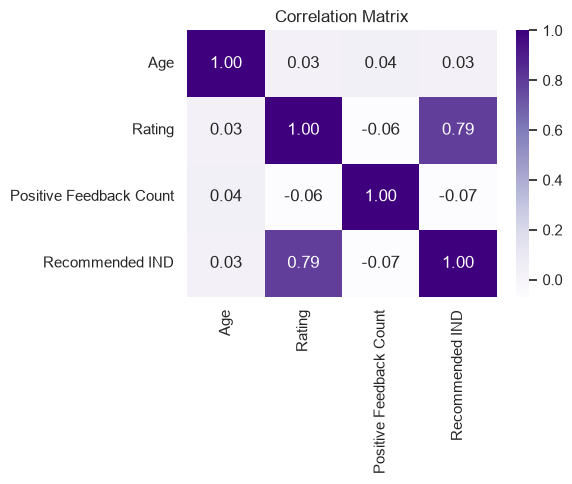

In [11]:
plt.figure(figsize=(6, 5))
corr = df_clean[["Age", "Rating", "Positive Feedback Count", "Recommended IND"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Purples")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_correlation_matrix.png", dpi=120)
plt.show()

## 6. Train / Validation / Test Split (70/15/15, stratified)

Stratification on `y` keeps the ~82/18 class ratio consistent across all three splits.

In [12]:
idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=RANDOM_SEED, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y.iloc[idx_temp])

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val, y_val = X.iloc[idx_val], y.iloc[idx_val]
X_test, y_test = X.iloc[idx_test], y.iloc[idx_test]
text_train, text_val, text_test = review_text.iloc[idx_train], review_text.iloc[idx_val], review_text.iloc[idx_test]
print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)

Train: (16415, 10)  Validation: (3518, 10)  Test: (3518, 10)


## 7. Preprocessing Pipeline (tabular)

Numeric columns: median imputation + `StandardScaler`. Categorical columns: most-frequent
imputation + `OneHotEncoder`. Fit **only** on `X_train`.

In [13]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),
                                   ("cat", categorical_pipeline, categorical_features)])
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)
print("Processed shapes:", X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)

Processed shapes: (16415, 35) (3518, 35) (3518, 35)


## 8. Baseline and Six Models

Baseline: `DummyClassifier(strategy="most_frequent")`. Five tabular models are trained on the
feature matrix above (Logistic Regression, Decision Tree, Random Forest, KNN, SVM), and a
sixth **text-based** model (TF-IDF + Logistic Regression) is trained directly on
`Review Text`, to compare a tabular-only representation against one that incorporates free
text — as required by the assignment.

In [14]:
def classification_metrics(y_true, y_pred, y_prob=None):
    m = {"Accuracy": accuracy_score(y_true, y_pred),
         "Precision": precision_score(y_true, y_pred, zero_division=0),
         "Recall": recall_score(y_true, y_pred, zero_division=0),
         "F1": f1_score(y_true, y_pred, zero_division=0)}
    if y_prob is not None:
        m["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    return m

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
baseline.fit(X_train_processed, y_train)
baseline_metrics = classification_metrics(y_val, baseline.predict(X_val_processed))
print("Baseline validation metrics:", baseline_metrics)

Baseline validation metrics: {'Accuracy': 0.8220579874928937, 'Precision': 0.8220579874928937, 'Recall': 1.0, 'F1': 0.9023400936037441}


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM": SVC(probability=True, random_state=RANDOM_SEED),
}

trained_models, val_results = {}, []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - t0
    pred = model.predict(X_val_processed)
    prob = model.predict_proba(X_val_processed)[:, 1]
    metrics = classification_metrics(y_val, pred, prob)
    metrics["Model"] = name; metrics["Training Time (s)"] = train_time
    val_results.append(metrics); trained_models[name] = model
    print(f"{name}: F1={metrics['F1']:.4f}")

Logistic Regression: F1=0.9528


Decision Tree: F1=0.9486


Random Forest: F1=0.9497


KNN: F1=0.9485


C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM: F1=0.9528


In [16]:
tfidf = TfidfVectorizer(lowercase=True, stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train_text = tfidf.fit_transform(text_train)
X_val_text = tfidf.transform(text_val)
X_test_text = tfidf.transform(text_test)
print("TF-IDF training shape:", X_train_text.shape, " (N x |vocabulary|)")

text_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
t0 = time.time()
text_model.fit(X_train_text, y_train)
text_train_time = time.time() - t0
text_pred = text_model.predict(X_val_text)
text_prob = text_model.predict_proba(X_val_text)[:, 1]
text_metrics = classification_metrics(y_val, text_pred, text_prob)
text_metrics["Model"] = "Text Logistic Regression (TF-IDF)"
text_metrics["Training Time (s)"] = text_train_time
val_results.append(text_metrics)
print("Text Logistic Regression (TF-IDF):", text_metrics)

TF-IDF training shape: (16415, 5000)  (N x |vocabulary|)
Text Logistic Regression (TF-IDF): {'Accuracy': 0.877771461057419, 'Precision': 0.8907936507936508, 'Recall': 0.9702627939142462, 'F1': 0.9288315127441245, 'ROC-AUC': 0.9168102819720811, 'Model': 'Text Logistic Regression (TF-IDF)', 'Training Time (s)': 0.09370541572570801}


In [17]:
val_df = pd.DataFrame(val_results).set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Training Time (s)"]]
val_df = val_df.sort_values("F1", ascending=False)
val_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
Model,,,,,,
SVM,0.924673,0.982018,0.925311,0.952822,0.965269,19.440045
Logistic Regression,0.923820,0.971942,0.934302,0.952750,0.966616,0.053647
Random Forest,0.918135,0.959421,0.940180,0.949703,0.956752,0.680763
Decision Tree,0.917567,0.973091,0.925311,0.948600,0.947642,0.051214
KNN,0.914156,0.935440,0.961964,0.948517,0.954833,0.001582
Text Logistic Regression (TF-IDF),0.877771,0.890794,0.970263,0.928832,0.916810,0.093705


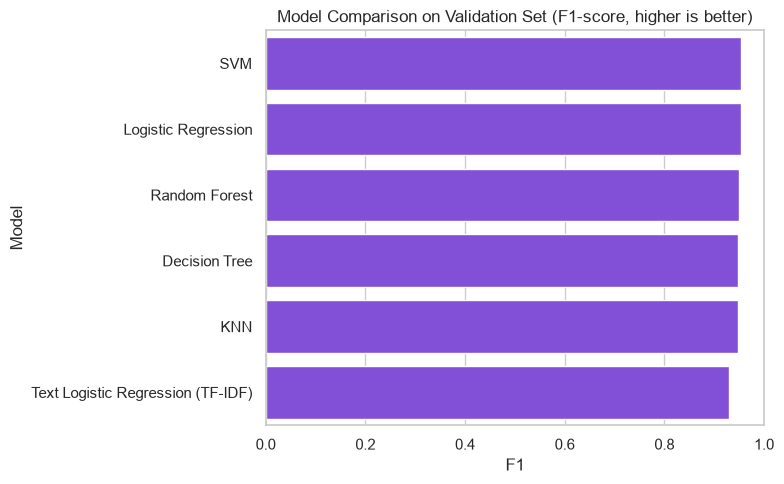

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=val_df["F1"], y=val_df.index, color="#7c3aed")
plt.title("Model Comparison on Validation Set (F1-score, higher is better)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_model_comparison.png", dpi=120)
plt.show()

**Observation:** the tabular models clearly outperform the text-only model, and `Rating`
is present only in the tabular representation — this matches the strong Rating-vs-target
correlation seen in the EDA. **Interpretation:** `Review Text` alone is a weaker predictor of
the *binary* recommend/do-not-recommend decision than the numeric rating and product
metadata combined. **ML implication:** the assignment's discussion question "does text
improve prediction compared with tabular features alone?" is answered **no** for this
target/dataset — text is informative on its own, but does not beat the tabular
representation. The **tabular** model with the highest F1 is selected for deployment.

## 9. Model Selection and Test Evaluation

The text-based model is excluded from deployment selection: it needs the customer's written
review, which is only available *after* a review has been submitted, making it unsuitable
for the same "predict whether this product will be recommended from its listing/customer
profile" deployment scenario as the tabular models.

In [19]:
tabular_val_df = val_df.drop(index="Text Logistic Regression (TF-IDF)")
best_model_name = tabular_val_df["F1"].idxmax()
best_model = trained_models[best_model_name]
print("Best deployable (tabular) model:", best_model_name)

test_pred = best_model.predict(X_test_processed)
test_prob = best_model.predict_proba(X_test_processed)[:, 1]
test_metrics = classification_metrics(y_test, test_pred, test_prob)
test_metrics

Best deployable (tabular) model: SVM


{'Accuracy': 0.9383172256964184,
 'Precision': 0.9886737303617099,
 'Recall': 0.9356846473029046,
 'F1': 0.9614496358145319,
 'ROC-AUC': 0.9777561986575284}

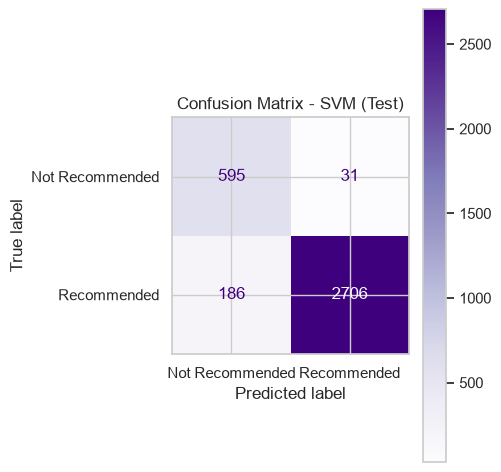

In [20]:
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Recommended", "Recommended"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Purples", colorbar=True)
plt.title(f"Confusion Matrix - {best_model_name} (Test)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_confusion_matrix_test.png", dpi=120)
plt.show()

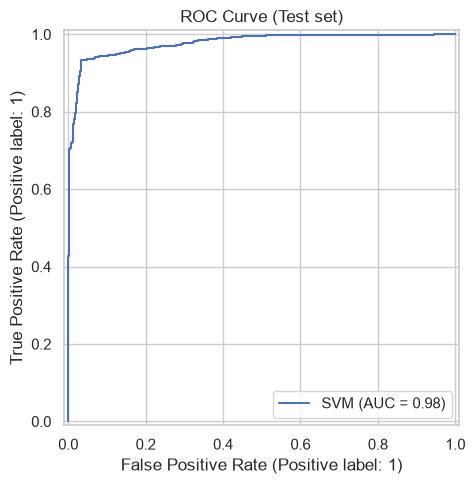

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, test_prob, ax=ax, name=best_model_name)
plt.title("ROC Curve (Test set)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_roc_curve_test.png", dpi=120)
plt.show()

## 10. Error Analysis

In [22]:
tn, fp, fn, tp = cm.ravel()
print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
print(f"Total={len(y_test)}  Correct={tp+tn}  Incorrect={fp+fn}")

TP=2706 TN=595 FP=31 FN=186
Total=3518  Correct=3301  Incorrect=217


**Observation:** false negatives (customers who recommend the product but the model
predicts "not recommended") outnumber false positives. **Interpretation:** the model is more
cautious about predicting a positive recommendation, consistent with `Precision` being much
higher than `Recall` on the test set. **ML implication:** in a business setting where
missing a genuinely enthusiastic customer is costly (e.g. for a loyalty/upsell campaign),
the classification threshold could be lowered to trade some precision for recall.

## 11. Model Persistence

The tabular preprocessing + selected model are bundled into one `Pipeline` and saved with
`joblib`. The TF-IDF + text-Logistic-Regression pipeline is saved separately as a secondary
artifact for analyzing free-text reviews directly (used by the "Analyze with AI" feature in
the web/mobile client).

In [23]:
full_pipeline = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
full_pipeline.fit(X_train, y_train)
joblib.dump(full_pipeline, f"{MODEL_DIR}/model_pipeline.joblib")

text_pipeline = Pipeline([("tfidf", tfidf), ("model", text_model)])
joblib.dump(text_pipeline, f"{MODEL_DIR}/text_model_pipeline.joblib")

categorical_options = {c: sorted(df_clean[c].unique().tolist()) for c in categorical_features}
meta = {
    "app": "ecommerce",
    "best_model_name": best_model_name,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_features,
    "categorical_cols": categorical_features,
    "categorical_options": categorical_options,
    "target_col": target_col,
    "class_labels": {"0": "Not recommended", "1": "Recommended"},
    "test_metrics": test_metrics,
    "validation_comparison": val_df.reset_index().to_dict(orient="records"),
    "baseline_metrics": baseline_metrics,
    "text_model_metrics": text_metrics,
    "random_seed": RANDOM_SEED,
}
with open(f"{MODEL_DIR}/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("Saved model_pipeline.joblib, text_model_pipeline.joblib and meta.json")

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Saved model_pipeline.joblib, text_model_pipeline.joblib and meta.json


## 12. Inference Test

In [24]:
loaded = joblib.load(f"{MODEL_DIR}/model_pipeline.joblib")
sample = pd.DataFrame([{
    "Age": 35, "Rating": 5, "Positive Feedback Count": 3,
    "Review Length": 180, "Title Length": 12, "Has Review": 1, "Has Title": 1,
    "Division Name": "General", "Department Name": "Dresses", "Class Name": "Dresses",
}])
proba = loaded.predict_proba(sample)[0]
print("P(recommended) =", proba[1])

loaded_text = joblib.load(f"{MODEL_DIR}/text_model_pipeline.joblib")
p = loaded_text.predict_proba(["Absolutely love this dress, fits perfectly and so comfortable!"])[0]
print("Text model P(recommended) =", p[1])

P(recommended) = 0.9999991302614978
Text model P(recommended) = 0.9986523517049474


## Discussion Questions (see report for full answers)

1. One observation = one customer review of one product.
2. Raw representation = CSV row with a mix of numeric, categorical and free-text columns.
3. Final numerical representation = a dense tabular feature matrix (scaled numeric + one-hot
   categorical) for the deployed model, and a sparse TF-IDF matrix for the text model.
4. `N` = number of reviews, `d` = number of encoded tabular columns (tabular model) or
   vocabulary size up to 5000 (text model).
5. Categorical: `Division Name`, `Department Name`, `Class Name` — one-hot encoded.
6. Numeric: `Age`, `Rating`, `Positive Feedback Count`, `Review Length`, `Title Length`,
   `Has Review`, `Has Title` — standardized.
7. Lost: exact wording of the review/title (tabular model only keeps their length and
   presence); rare vocabulary terms beyond the 5000-word TF-IDF budget (text model).
8. Preserved: rating, product category, review-writing behaviour (tabular); the most
   discriminative words/bigrams (text model).
9. Fitting `StandardScaler`/`OneHotEncoder`/`TfidfVectorizer` on data outside the training
   split (e.g. the full dataset before splitting) would leak information.
10–15. See `model/meta.json` for the selected model, its metrics, and deployment details.
